# Difference-in-Differences Project: AI Shopping Assistant

## Business Problem

An e-commerce app launched an AI shopping assistant in selected cities.

The business wants to know:

Did the AI shopping assistant increase 30-day customer retention?

## Method

I will use Difference-in-Differences.

This method compares:

1. Treatment cities before and after launch
2. Control cities before and after launch

The key idea is simple:

If treatment cities improved more than control cities after launch, the extra improvement may be the effect of the AI assistant.

In [2]:
import sys

!{sys.executable} -m pip install pandas numpy matplotlib statsmodels

  Using cached patsy-1.0.2-py2.py3-none-any.whl.metadata (3.6 kB)
   ---------------------------------------- 0.0/9.6 MB ? eta -:--:--
   - -------------------------------------- 0.3/9.6 MB ? eta -:--:--
   -------- ------------------------------- 2.1/9.6 MB 6.9 MB/s eta 0:00:02
   ------------- -------------------------- 3.1/9.6 MB 6.4 MB/s eta 0:00:02
   ------------------- -------------------- 4.7/9.6 MB 6.8 MB/s eta 0:00:01
   ------------------------- -------------- 6.0/9.6 MB 6.7 MB/s eta 0:00:01
   ------------------------------ --------- 7.3/9.6 MB 7.0 MB/s eta 0:00:01
   ------------------------------------- -- 8.9/9.6 MB 6.8 MB/s eta 0:00:01
   ---------------------------------------- 9.6/9.6 MB 6.7 MB/s  0:00:01
Using cached patsy-1.0.2-py2.py3-none-any.whl (233 kB)

   -------------------- ------------------- 1/2 [statsmodels]
   -------------------- ------------------- 1/2 [statsmodels]
   -------------------- ------------------- 1/2 [statsmodels]
   -------------------- -

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf

## Load the Dataset

The dataset contains user-level data from treatment and control cities.

Treatment cities received the AI shopping assistant.

Control cities did not receive the AI shopping assistant.

In [4]:
df = pd.read_csv("../data/ecommerce_ai_assistant_did.csv")

df.head()

,user_id,cohort_month,city,treatment_city,post_launch,did,age,income,prior_orders_90d,prior_spend_90d,app_sessions_30d,days_since_last_purchase,premium_member,mobile_app_user,marketing_emails_30d,discount_received,retained_30d,spend_30d
0,1,2025-04-01,Denver,0,0,0,22,79972,1,171.74,6,6,0,1,4,0,1,121.26
1,2,2025-12-01,Seattle,1,1,1,59,81855,0,50.94,8,12,0,0,5,1,1,105.39
2,3,2025-10-01,New York,1,1,1,36,94044,2,183.06,9,31,0,1,3,1,0,67.47
3,4,2025-08-01,Austin,1,1,1,44,95282,2,99.51,4,7,1,1,7,0,1,159.49
4,5,2025-12-01,New York,1,1,1,19,98062,3,177.64,5,3,1,0,9,0,1,150.59


In [5]:
df.shape

(12000, 18)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12000 entries, 0 to 11999
Data columns (total 18 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   user_id                   12000 non-null  int64  
 1   cohort_month              12000 non-null  object 
 2   city                      12000 non-null  object 
 3   treatment_city            12000 non-null  int64  
 4   post_launch               12000 non-null  int64  
 5   did                       12000 non-null  int64  
 6   age                       12000 non-null  int64  
 7   income                    12000 non-null  int64  
 8   prior_orders_90d          12000 non-null  int64  
 9   prior_spend_90d           12000 non-null  float64
 10  app_sessions_30d          12000 non-null  int64  
 11  days_since_last_purchase  12000 non-null  int64  
 12  premium_member            12000 non-null  int64  
 13  mobile_app_user           12000 non-null  int64  
 14  market

## Understand the Dataset

Before running Difference-in-Differences, I need to understand the main variables.

The most important columns are:

- `treatment_city`: 1 if the city received the AI assistant, 0 otherwise
- `post_launch`: 1 if the row is after the launch date, 0 otherwise
- `did`: interaction between treatment city and post-launch period
- `retained_30d`: main outcome
- `spend_30d`: secondary outcome

In [7]:
df[["city", "cohort_month", "treatment_city", "post_launch", "did", "retained_30d", "spend_30d"]].head(10)

,city,cohort_month,treatment_city,post_launch,did,retained_30d,spend_30d
0,Denver,2025-04-01,0,0,0,1,121.26
1,Seattle,2025-12-01,1,1,1,1,105.39
2,New York,2025-10-01,1,1,1,0,67.47
3,Austin,2025-08-01,1,1,1,1,159.49
4,New York,2025-12-01,1,1,1,1,150.59
5,Austin,2025-09-01,1,1,1,1,115.16
6,Denver,2025-05-01,0,0,0,1,109.29
7,Austin,2025-07-01,1,1,1,1,127.90
8,Austin,2025-03-01,1,0,0,0,72.61
9,Phoenix,2025-11-01,0,1,0,0,94.92


In [8]:
df[["treatment_city", "post_launch", "did", "retained_30d", "spend_30d"]].describe()

,treatment_city,post_launch,did,retained_30d,spend_30d
count,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000
mean,0.490333,0.506583,0.248167,0.455833,95.197873
std,0.499927,0.499977,0.431967,0.498066,38.307414
min,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,67.800000
50%,0.000000,1.000000,0.000000,0.000000,94.815000
75%,1.000000,1.000000,0.000000,1.000000,121.932500
max,1.000000,1.000000,1.000000,1.000000,241.470000


## Visual Trend Check

Before running the regression, I want to compare retention trends over time.

This helps me check whether treatment cities and control cities looked similar before the AI assistant launch.

If the pre-launch trends look similar, Difference-in-Differences is more credible.

In [14]:
df["cohort_month"] = pd.to_datetime(df["cohort_month"])

df["group"] = np.where(
    df["treatment_city"] == 1,
    "Treatment Cities",
    "Control Cities"
)

df[["cohort_month", "city", "group", "treatment_city", "post_launch", "did"]].head()

,cohort_month,city,group,treatment_city,post_launch,did
0,2025-04-01,Denver,Control Cities,0,0,0
1,2025-12-01,Seattle,Treatment Cities,1,1,1
2,2025-10-01,New York,Treatment Cities,1,1,1
3,2025-08-01,Austin,Treatment Cities,1,1,1
4,2025-12-01,New York,Treatment Cities,1,1,1


In [15]:
monthly_retention = (
    df.groupby(["cohort_month", "group"])["retained_30d"]
    .mean()
    .reset_index()
)

monthly_retention["retention_rate"] = monthly_retention["retained_30d"] * 100

monthly_retention.head()

,cohort_month,group,retained_30d,retention_rate
0,2025-01-01,Control Cities,0.447876,44.787645
1,2025-01-01,Treatment Cities,0.453799,45.379877
2,2025-02-01,Control Cities,0.410256,41.025641
3,2025-02-01,Treatment Cities,0.415289,41.528926
4,2025-03-01,Control Cities,0.397177,39.717742


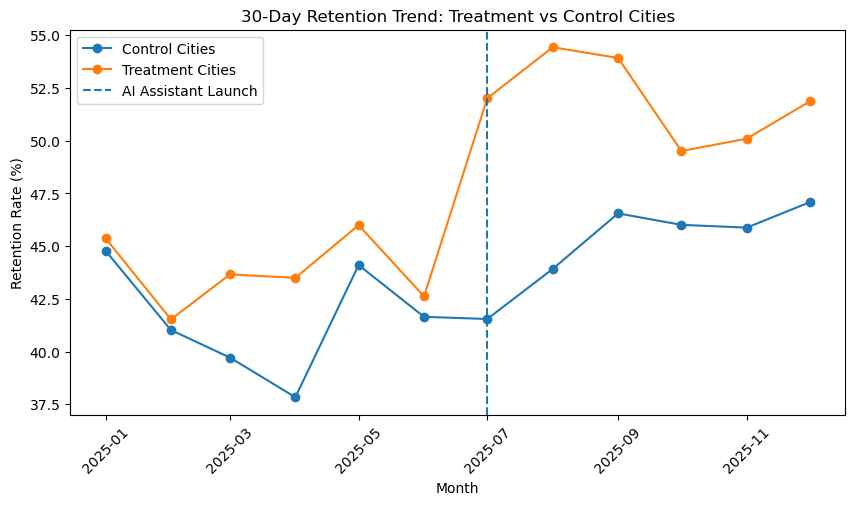

In [16]:
plt.figure(figsize=(10, 5))

for group in monthly_retention["group"].unique():
    temp = monthly_retention[monthly_retention["group"] == group]
    plt.plot(
        temp["cohort_month"],
        temp["retention_rate"],
        marker="o",
        label=group
    )

plt.axvline(
    pd.Timestamp("2025-07-01"),
    linestyle="--",
    label="AI Assistant Launch"
)

plt.title("30-Day Retention Trend: Treatment vs Control Cities")
plt.xlabel("Month")
plt.ylabel("Retention Rate (%)")
plt.legend()
plt.xticks(rotation=45)
plt.show()

## Parallel Trend Check

Difference-in-Differences depends on the parallel trend assumption.

This means treatment cities and control cities should have similar trends before the AI assistant launch.

I will check this in two ways:

1. Visual check before launch
2. Simple pre-launch regression test

If treatment and control cities had similar pre-launch trends, the DiD estimate is more credible.

In [20]:
city_month = (
    df.groupby(["city", "cohort_month", "treatment_city", "post_launch"])["retained_30d"]
    .mean()
    .reset_index()
)

city_month["retention_rate"] = city_month["retained_30d"] * 100

pre_launch = city_month[city_month["post_launch"] == 0].copy()

pre_launch.head()

,city,cohort_month,treatment_city,post_launch,retained_30d,retention_rate
0,Austin,2025-01-01,1,0,0.492537,49.253731
1,Austin,2025-02-01,1,0,0.436508,43.650794
2,Austin,2025-03-01,1,0,0.420635,42.063492
3,Austin,2025-04-01,1,0,0.431373,43.137255
4,Austin,2025-05-01,1,0,0.487179,48.717949


In [21]:
pre_trend = (
    pre_launch.groupby(["cohort_month", "treatment_city"])["retention_rate"]
    .mean()
    .reset_index()
)

pre_trend["group"] = np.where(
    pre_trend["treatment_city"] == 1,
    "Treatment Cities",
    "Control Cities"
)

pre_trend

,cohort_month,treatment_city,retention_rate,group
0,2025-01-01,0,44.877465,Control Cities
1,2025-01-01,1,45.100933,Treatment Cities
2,2025-02-01,0,41.074603,Control Cities
3,2025-02-01,1,41.429538,Treatment Cities
4,2025-03-01,0,39.734934,Control Cities
5,2025-03-01,1,43.706554,Treatment Cities
6,2025-04-01,0,37.822305,Control Cities
7,2025-04-01,1,43.345990,Treatment Cities
8,2025-05-01,0,44.242765,Control Cities
9,2025-05-01,1,45.914746,Treatment Cities


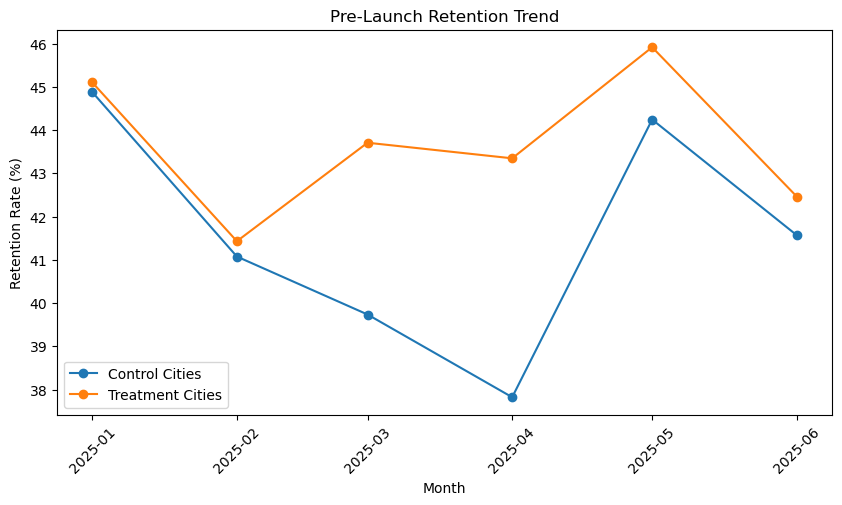

In [22]:
plt.figure(figsize=(10, 5))

for group in pre_trend["group"].unique():
    temp = pre_trend[pre_trend["group"] == group]
    plt.plot(
        temp["cohort_month"],
        temp["retention_rate"],
        marker="o",
        label=group
    )

plt.title("Pre-Launch Retention Trend")
plt.xlabel("Month")
plt.ylabel("Retention Rate (%)")
plt.legend()
plt.xticks(rotation=45)
plt.show()

### Pre-Launch Regression Test

The chart gives a visual check.

Now I will run a simple regression using only pre-launch data.

The model checks whether treatment cities had a different pre-launch trend from control cities.

The key term is:

`treatment_city:month_index`

If this term is not statistically significant, that supports the parallel trend assumption.

In [23]:
pre_launch["month_index"] = pre_launch["cohort_month"].dt.month

parallel_model = smf.ols(
    "retention_rate ~ treatment_city * month_index",
    data=pre_launch
).fit()

parallel_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:         retention_rate   R-squared:                       0.065
Model:                            OLS   Adj. R-squared:                  0.001
Method:                 Least Squares   F-statistic:                     1.022
Date:                Thu, 25 Jun 2026   Prob (F-statistic):              0.392
Time:                        15:31:35   Log-Likelihood:                -136.52
No. Observations:                  48   AIC:                             281.0
Df Residuals:                      44   BIC:                             288.5
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
==============================================================================================
                                 coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------
Intercept                     42.4491      2.022     20.996      0.000      38.374      46.524
treatment_city                 1.2210      2.859      0.427      0.671      -4.541       6.983
month_index                   -0.2560      0.519     -0.493      0.624      -1.302       0.790
treatment_city:month_index     0.2530      0.734      0.345      0.732      -1.227       1.733
==============================================================================
Omnibus:                        1.020   Durbin-Watson:                   2.106
Prob(Omnibus):                  0.600   Jarque-Bera (JB):                0.594
Skew:                          -0.270   Prob(JB):                        0.743
Kurtosis:                       3.081   Cond. No.                         24.5
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

The pre-launch chart shows that treatment and control cities moved in a similar direction before launch.

The pre-trend regression does not show strong evidence that treatment and control cities had different pre-launch trends.

This supports the parallel trend assumption, so Difference-in-Differences is reasonable for this project.

## Basic DiD Table

Before running the regression, I calculate the DiD estimate manually.

This is a simple check.

The formula is:

Treatment change - Control change

This helps me see whether treatment cities improved more than control cities after the AI assistant launch.

In [24]:
did_summary = (
    df.groupby(["treatment_city", "post_launch"])
    .agg(
        retention_rate=("retained_30d", "mean"),
        users=("user_id", "count")
    )
    .reset_index()
)

did_summary["retention_rate"] = did_summary["retention_rate"] * 100

did_summary

,treatment_city,post_launch,retention_rate,users
0,0,0,41.558872,3015
1,0,1,45.114479,3101
2,1,0,43.737096,2906
3,1,1,51.947616,2978


In [25]:
did_table = did_summary.pivot(
    index="treatment_city",
    columns="post_launch",
    values="retention_rate"
)

did_table.columns = ["Before Launch", "After Launch"]

did_table["Change"] = did_table["After Launch"] - did_table["Before Launch"]

did_table

,Before Launch,After Launch,Change
treatment_city,,,
0,41.558872,45.114479,3.555607
1,43.737096,51.947616,8.210520


In [26]:
control_change = did_table.loc[0, "Change"]
treatment_change = did_table.loc[1, "Change"]

manual_did = treatment_change - control_change

print("Control change:", round(control_change, 2), "percentage points")
print("Treatment change:", round(treatment_change, 2), "percentage points")
print("Manual DiD estimate:", round(manual_did, 2), "percentage points")

Control change: 3.56 percentage points
Treatment change: 8.21 percentage points
Manual DiD estimate: 4.65 percentage points


### Manual DiD Interpretation

The control cities also improved after launch.

Because of that, I should not only compare treatment cities before and after launch.

I need to subtract the control group change.

The manual DiD estimate shows the extra improvement in treatment cities after removing the general improvement seen in control cities.

This is only a simple check.

The next step is the real DiD regression, where I estimate the interaction term and check statistical significance.

## DiD Regression

Now I run the main Difference-in-Differences regression.

The model is:

retained_30d = treatment_city + post_launch + did

Where:

- `treatment_city` compares treatment cities to control cities
- `post_launch` compares the post-launch period to the pre-launch period
- `did` is the interaction term

The coefficient on `did` is the main treatment effect.

If the `did` coefficient is positive and statistically significant, it suggests the AI assistant increased retention.

In [29]:
did_model = smf.ols(
    "retained_30d ~ treatment_city + post_launch + did",
    data=df
).fit(cov_type="HC1")

did_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:           retained_30d   R-squared:                       0.006
Model:                            OLS   Adj. R-squared:                  0.006
Method:                 Least Squares   F-statistic:                     24.23
Date:                Thu, 25 Jun 2026   Prob (F-statistic):           1.26e-15
Time:                        15:39:43   Log-Likelihood:                -8626.1
No. Observations:               12000   AIC:                         1.726e+04
Df Residuals:                   11996   BIC:                         1.729e+04
Df Model:                           3                                         
Covariance Type:                  HC1                                         
==================================================================================
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept          0.4156      0.009     46.296      0.000       0.398       0.433
treatment_city     0.0218      0.013      1.694      0.090      -0.003       0.047
post_launch        0.0356      0.013      2.807      0.005       0.011       0.060
did                0.0465      0.018      2.566      0.010       0.011       0.082
==============================================================================
Omnibus:                    42644.212   Durbin-Watson:                   2.020
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             1952.467
Skew:                           0.176   Prob(JB):                         0.00
Kurtosis:                       1.056   Cond. No.                         6.84
==============================================================================

Notes:
[1] Standard Errors are heteroscedasticity robust (HC1)
"""

### Basic DiD Regression Result

The key coefficient is `did`.

This is the interaction between treatment city and post-launch period.

It estimates how much more retention changed in treatment cities after launch compared with control cities.

The coefficient is positive, which means retention increased more in treatment cities.

If the p-value is below 0.05, the effect is statistically significant.

This model is useful as a simple baseline.

Next, I will improve the model by adding city fixed effects, month fixed effects, and user-level control variables.

## DiD Regression with Fixed Effects

The basic DiD model is useful, but it does not control for city-level or month-level differences.

Now I add fixed effects.

City fixed effects control for permanent differences across cities.

Month fixed effects control for common time shocks that affect all cities.

The model is:

retained_30d = did + city fixed effects + month fixed effects

The key coefficient is still `did`.

In [31]:
fe_model = smf.ols(
    "retained_30d ~ did + C(city) + C(cohort_month)",
    data=df
).fit(cov_type="HC1")

fe_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:           retained_30d   R-squared:                       0.007
Model:                            OLS   Adj. R-squared:                  0.006
Method:                 Least Squares   F-statistic:                     4.712
Date:                Thu, 25 Jun 2026   Prob (F-statistic):           4.50e-11
Time:                        15:42:52   Log-Likelihood:                -8618.0
No. Observations:               12000   AIC:                         1.728e+04
Df Residuals:                   11980   BIC:                         1.742e+04
Df Model:                          19                                         
Covariance Type:                  HC1                                         
=======================================================================================================================
                                                          coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------------------------
Intercept                                               0.4579      0.020     22.542      0.000       0.418       0.498
C(city)[T.Boston]                                      -0.0008      0.018     -0.045      0.964      -0.037       0.035
C(city)[T.Chicago]                                     -0.0142      0.020     -0.705      0.481      -0.054       0.025
C(city)[T.Dallas]                                      -0.0288      0.020     -1.424      0.155      -0.068       0.011
C(city)[T.Denver]                                       0.0022      0.020      0.108      0.914      -0.038       0.042
C(city)[T.New York]                                     0.0162      0.018      0.880      0.379      -0.020       0.052
C(city)[T.Phoenix]                                     -0.0290      0.020     -1.435      0.151      -0.069       0.011
C(city)[T.Seattle]                                      0.0034      0.018      0.185      0.853      -0.033       0.039
C(cohort_month)[T.Timestamp('2025-02-01 00:00:00')]    -0.0386      0.022     -1.741      0.082      -0.082       0.005
C(cohort_month)[T.Timestamp('2025-03-01 00:00:00')]    -0.0346      0.022     -1.557      0.119      -0.078       0.009
C(cohort_month)[T.Timestamp('2025-04-01 00:00:00')]    -0.0458      0.023     -2.034      0.042      -0.090      -0.002
C(cohort_month)[T.Timestamp('2025-05-01 00:00:00')]    -0.0008      0.023     -0.035      0.972      -0.045       0.043
C(cohort_month)[T.Timestamp('2025-06-01 00:00:00')]    -0.0304      0.022     -1.390      0.165      -0.073       0.012
C(cohort_month)[T.Timestamp('2025-07-01 00:00:00')]    -0.0075      0.024     -0.315      0.753      -0.054       0.039
C(cohort_month)[T.Timestamp('2025-08-01 00:00:00')]     0.0177      0.024      0.740      0.460      -0.029       0.065
C(cohort_month)[T.Timestamp('2025-09-01 00:00:00')]     0.0283      0.024      1.168      0.243      -0.019       0.076
C(cohort_month)[T.Timestamp('2025-10-01 00:00:00')]     0.0032      0.024      0.134      0.893      -0.044       0.050
C(cohort_month)[T.Timestamp('2025-11-01 00:00:00')]     0.0060      0.024      0.253      0.800      -0.041       0.053
C(cohort_month)[T.Timestamp('2025-12-01 00:00:00')]     0.0205      0.024      0.863      0.388      -0.026       0.067
did                                                     0.0455      0.018      2.506      0.012       0.010       0.081
==============================================================================
Omnibus:                    42781.033   Durbin-Watson:                   2.018
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             1942.111
Skew:                           0.176   Prob(JB):                         0.00
Kurtosi

In [32]:
fe_coef = fe_model.params["did"]
fe_pvalue = fe_model.pvalues["did"]
fe_ci = fe_model.conf_int().loc["did"]

print("DiD coefficient:", round(fe_coef, 4))
print("Effect in percentage points:", round(fe_coef * 100, 2))
print("P-value:", round(fe_pvalue, 4))
print("95% confidence interval:")
print(round(fe_ci[0] * 100, 2), "to", round(fe_ci[1] * 100, 2), "percentage points")

DiD coefficient: 0.0455
Effect in percentage points: 4.55
P-value: 0.0122
95% confidence interval:
0.99 to 8.11 percentage points


## Model Comparison

Now I compare the DiD coefficient across different model versions.

This helps check whether the result is stable.

If the `did` coefficient stays positive and significant across models, the result is more credible.

In [37]:
model_comparison = pd.DataFrame({
    "Model": [
        "Basic DiD",
        "City + Month Fixed Effects"
    ],
    "DiD Coefficient": [
        did_model.params["did"],
        fe_model.params["did"]
    ],
    "Effect in Percentage Points": [
        did_model.params["did"] * 100,
        fe_model.params["did"] * 100
    ],
    "P-Value": [
        did_model.pvalues["did"],
        fe_model.pvalues["did"]
    ],
    "R-Squared": [
        did_model.rsquared,
        fe_model.rsquared
    ]
})

model_comparison.round(4)

,Model,DiD Coefficient,Effect in Percentage Points,P-Value,R-Squared
0,Basic DiD,0.0465,4.6549,0.0103,0.0060
1,City + Month Fixed Effects,0.0455,4.5483,0.0122,0.0074


### Model Comparison Interpretation

The DiD coefficient stays positive across all models.



## Final Recommendation

Based on the Difference-in-Differences analysis, I recommend expanding the AI shopping assistant to more cities.

The model estimates that the AI assistant increased 30-day retention by **4.55 percentage points**.

This result is statistically significant because the p-value is **0.0122**, which is below **0.05**.

This means the estimated effect is positive and unlikely to be random noise based on this model.

The result is also practically meaningful because the effect is larger than the 1 percentage point business threshold.

### Business Decision

The company should continue the rollout of the AI shopping assistant.

Before a full launch, I would monitor guardrail metrics such as:

- 30-day spending
- app sessions
- customer support tickets
- discount usage
- model cost
- user complaints

If these guardrail metrics do not get worse, the company should expand the AI assistant to more cities.

